In [1]:
import os
import requests
import tiktoken
import numpy as np
import random
import torch
from torch import nn
import math

In [2]:
class Tokenizer():
    def __init__(self, vocab: list[str]):
        self.vocab_size = len(vocab)
        self.stoi = {c: i for i, c in enumerate(vocab)}
        self.itos = {i: c for i, c in enumerate(vocab)}


    @classmethod
    def from_text(cls, text: str) -> "Tokenizer":
        vocab = sorted(set(text))
        return cls(vocab)


    def encode(self, x):
        return [self.stoi[c] for c in x]


    def decode(self, x):
        return "".join([self.itos[i] for i in x])

In [3]:
class CausalSelfAttention(nn.Module):
    def __init__(self, T, d_m, h):
        super().__init__()
        self.d_k = int(d_m / h)
        self.d_v = int(d_m / h)
        self.h = h

        self.W_Q = nn.Parameter(torch.randn((d_m, self.d_k * self.h)))
        self.W_K = nn.Parameter(torch.randn((d_m, self.d_k * self.h)))
        self.W_V = nn.Parameter(torch.randn((d_m, self.d_v * self.h)))
        self.register_buffer("M", torch.triu(torch.ones(T, T) * -torch.inf, diagonal=1))
        self.W_attn_out = nn.Parameter(torch.randn((h * self.d_v, d_m)))


    def forward(self, x):
        Q = x @ self.W_Q
        K = x @ self.W_K
        V = x @ self.W_V
        Q = Q.reshape((x.shape[0], x.shape[1], self.h, self.d_k)).permute(0, 2, 1, 3)  # (B, T, h, d_k) -> (B, h, T, d_k)
        K = K.reshape((x.shape[0], x.shape[1], self.h, self.d_k)).permute(0, 2, 1, 3)  # (B, T, h, d_k) -> (B, h, T, d_k)
        V = V.reshape((x.shape[0], x.shape[1], self.h, self.d_v)).permute(0, 2, 1, 3)  # (B, T, h, d_k) -> (B, h, T, d_k)
        S = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)
        seq_len = x.shape[1]
        M = self.M[:seq_len, :seq_len].unsqueeze(0).unsqueeze(0)  # (1, 1, T, T)
        P = torch.softmax(S + M, dim=-1)
        O = P @ V
        O = O.permute(0, 2, 1, 3).reshape(x.shape[0], x.shape[1], self.h * self.d_v)  # (B, h, T, d_v) -> (B, T, h, d_v) -> (B, T, h * d_v)
        out = O @ self.W_attn_out
        return out
    

class TransformerBlock(nn.Module):
    def __init__(self, T, d_m, h, d_ff):
        super().__init__()
        self.attn = CausalSelfAttention(T, d_m, h)
        self.layer_norm1 = nn.LayerNorm(d_m)

        self.l1 = nn.Linear(d_m, d_ff)
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(d_ff, d_m)

        self.layer_norm2 = nn.LayerNorm(d_m)

    
    def forward(self, x):
        x_attn = self.attn(x)
        x_add_norm1 = self.layer_norm1(x_attn + x) 
        x_ff = self.l2(self.relu(self.l1(x_add_norm1)))
        x_add_norm2 = self.layer_norm2(x_ff + x_add_norm1)
        return x_add_norm2
    

class ToyGPT(nn.Module):
    def __init__(self, T, vocab_size, L, h, d_m, d_ff):
        super().__init__()
        self.E = nn.Parameter(torch.randn((vocab_size, d_m)))
        self.P = nn.Parameter(torch.randn((T, d_m)))

        self.blocks = nn.ModuleList([TransformerBlock(T, d_m, h, d_ff) for _ in range(L)])

        self.proj = nn.Linear(d_m, vocab_size)


    def forward(self, x):
        seq_len = x.shape[1]
        x_emb = self.E[x] + self.P[:seq_len]
        x = x_emb
        for block in self.blocks:
            x = block(x)
        logits = self.proj(x)
        return logits

In [4]:
input_file_path = '../data/tinyshakespeare/input.txt'

with open(input_file_path, 'r', encoding='utf-8') as f:
    data = f.read()
n = len(data)
train_data = data[:int(n*0.9)]
val_data = data[int(n*0.9):]

tok = Tokenizer.from_text(data)
train_ids = torch.tensor(tok.encode(train_data), dtype=torch.long)
val_ids = torch.tensor(tok.encode(val_data), dtype=torch.long)
print(f"train_tokens: {len(train_ids):,}")
print(f"val_tokens: {len(val_ids):,}")

train_tokens: 1,003,854
val_tokens: 111,540


In [6]:
def get_batch(data, batch_size, seq_len):
    Xs = []
    Ys = []
    for _ in range(batch_size):
        i = random.randrange(0, len(data) - seq_len)
        x = data[i : i + seq_len].clone().detach()
        y = data[i + 1 : i + seq_len + 1].clone().detach()
        Xs.append(x)
        Ys.append(y)
    X = torch.stack(Xs)
    Y = torch.stack(Ys)
    return X, Y


In [21]:
@torch.no_grad()
def estimate_loss(n, model, loss_fn, train_ids, val_ids, B, T):
    model.eval()

    def _forward(data, B, T):
        x, y = get_batch(data, B, T)
        logits = model(x)
        loss = loss_fn(logits.permute(0, 2, 1), y)
        return loss.item()
    
    train_loss = 0.0
    val_loss = 0.0
    for _ in range(n):
        train_loss += _forward(train_ids, B, T)
        val_loss += _forward(val_ids, B, T)

    train_loss /= n
    val_loss /= n
    
    model.train()
    return train_loss, val_loss
        

In [31]:
B = 8
T = 32  # context, block_size
L = 6
h = 6
d_m = 384
d_ff = 1536

In [32]:
model = ToyGPT(T, tok.vocab_size, L, h, d_m, d_ff)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

In [33]:
def train(train_ids, val_ids, model, optimizer, loss_fn, epochs, eval_interval, eval_batches, B, T):
    train_hist = []
    val_hist = []
    for e in range(epochs):
        optimizer.zero_grad()
        x, y = get_batch(train_ids, B, T)
        logits = model(x)
        loss = loss_fn(logits.permute(0, 2, 1), y)
        loss.backward()
        optimizer.step()

        if e % eval_interval == 0:
            train_loss, val_loss = estimate_loss(eval_batches, model, loss_fn, train_ids, val_ids, B, T)
            print(f"{e}/{epochs}: train: {train_loss}, val_loss: {val_loss}")
            train_hist.append(train_loss)
            val_hist.append(val_loss)

    return train_hist, val_hist

In [34]:
epochs = 2000
eval_interval = 100
eval_batches = 50

train_hist, val_hist = train(train_ids, val_ids, model, optimizer, loss_fn, epochs, eval_interval, eval_batches, B, T)

0/2000: train: 4.194240875244141, val_loss: 4.182157115936279
100/2000: train: 3.450571656227112, val_loss: 3.444739193916321
200/2000: train: 3.367682375907898, val_loss: 3.4019056224822997
300/2000: train: 3.3300587558746337, val_loss: 3.364907898902893
400/2000: train: 3.336801495552063, val_loss: 3.3861157369613646
500/2000: train: 3.3415028619766236, val_loss: 3.3741510343551635
600/2000: train: 3.3449051141738892, val_loss: 3.3514034509658814
700/2000: train: 3.3230203008651733, val_loss: 3.364345016479492
800/2000: train: 3.3101593112945555, val_loss: 3.3708272266387937
900/2000: train: 3.317542772293091, val_loss: 3.3622235441207886
1000/2000: train: 3.324776306152344, val_loss: 3.3627950954437256
1100/2000: train: 3.332004418373108, val_loss: 3.363607177734375
1200/2000: train: 3.2943078470230103, val_loss: 3.3730222034454345
1300/2000: train: 3.3371226358413697, val_loss: 3.347989101409912
1400/2000: train: 3.317225441932678, val_loss: 3.358354344367981
1500/2000: train: 3.28

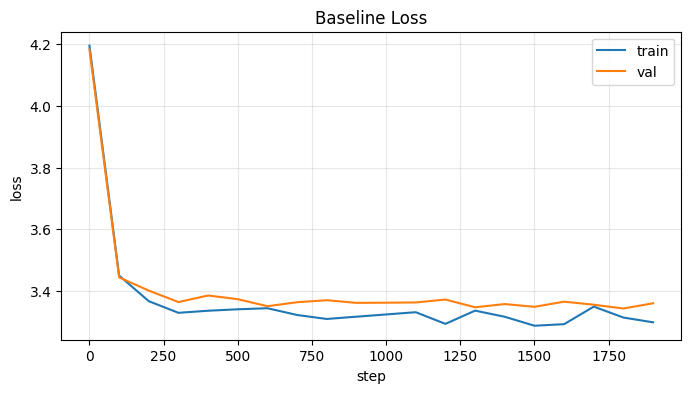

In [35]:
import matplotlib.pyplot as plt

eval_steps = list(range(0, epochs, eval_interval))
eval_steps = eval_steps[:len(train_hist)]

plt.figure(figsize=(8, 4))
plt.plot(eval_steps, train_hist, label='train')
plt.plot(eval_steps, val_hist, label='val')
plt.xlabel('step')
plt.ylabel('loss')
plt.title('Baseline Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()